In [ ]:
#Sarah Qaiser Sahaf
#SP24-BBD-128

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Set display options for cleaner output
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 50)

In [2]:
csv_path = r"C:\Users\THIS PC\Downloads\UCI_Credit_Card.csv"
df = pd.read_csv(csv_path)

# Keep only UCI naming convention
if "ID" in df.columns:
    df = df.drop(columns=["ID"])
if "PAY_0" in df.columns:
    df = df.rename(columns={"PAY_0": "PAY_1"})

target_col = "default.payment.next.month"
X = df.drop(columns=[target_col]).copy()
y = df[[target_col]].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())
display(y.head())
X.info()

Features shape: (30000, 23)
Target shape: (30000, 1)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0000,2,2,1,24,2,2,-1,-1,-2,-2,3913.0000,3102.0000,689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000
1,120000.0000,2,2,2,26,-1,2,0,0,0,2,2682.0000,1725.0000,2682.0000,3272.0000,3455.0000,3261.0000,0.0000,1000.0000,1000.0000,1000.0000,0.0000,2000.0000
2,90000.0000,2,2,2,34,0,0,0,0,0,0,29239.0000,14027.0000,13559.0000,14331.0000,14948.0000,15549.0000,1518.0000,1500.0000,1000.0000,1000.0000,1000.0000,5000.0000
3,50000.0000,2,2,1,37,0,0,0,0,0,0,46990.0000,48233.0000,49291.0000,28314.0000,28959.0000,29547.0000,2000.0000,2019.0000,1200.0000,1100.0000,1069.0000,1000.0000
4,50000.0000,1,2,1,57,-1,0,-1,0,0,0,8617.0000,5670.0000,35835.0000,20940.0000,19146.0000,19131.0000,2000.0000,36681.0000,10000.0000,9000.0000,689.0000,679.0000


,default.payment.next.month
0,1
1,1
2,0
3,0
4,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_1      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

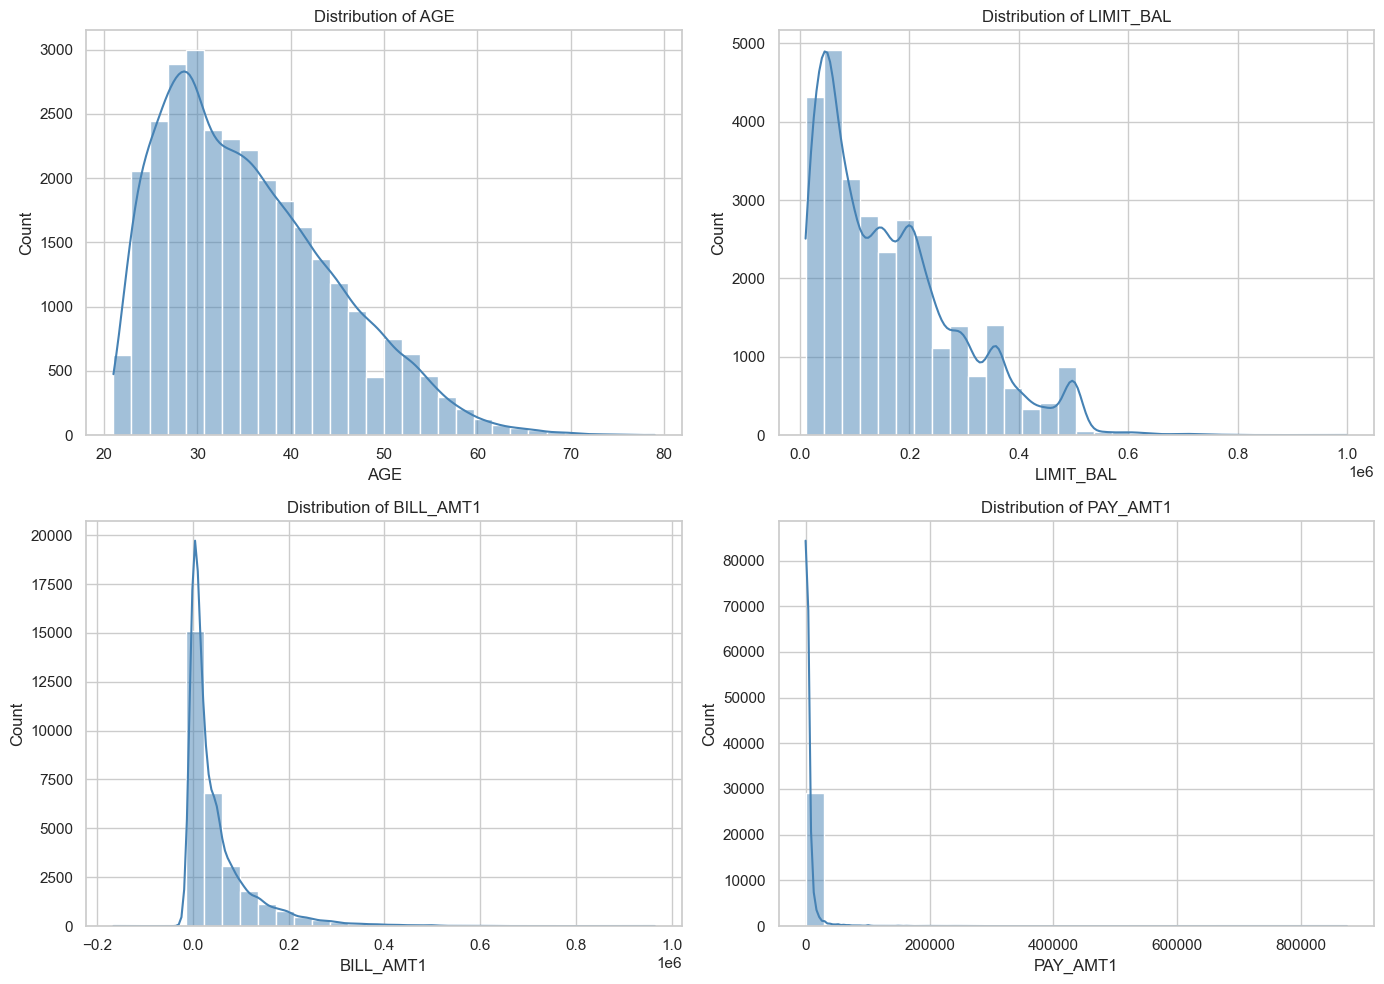

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_cols = ["AGE", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]

for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(X[col], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

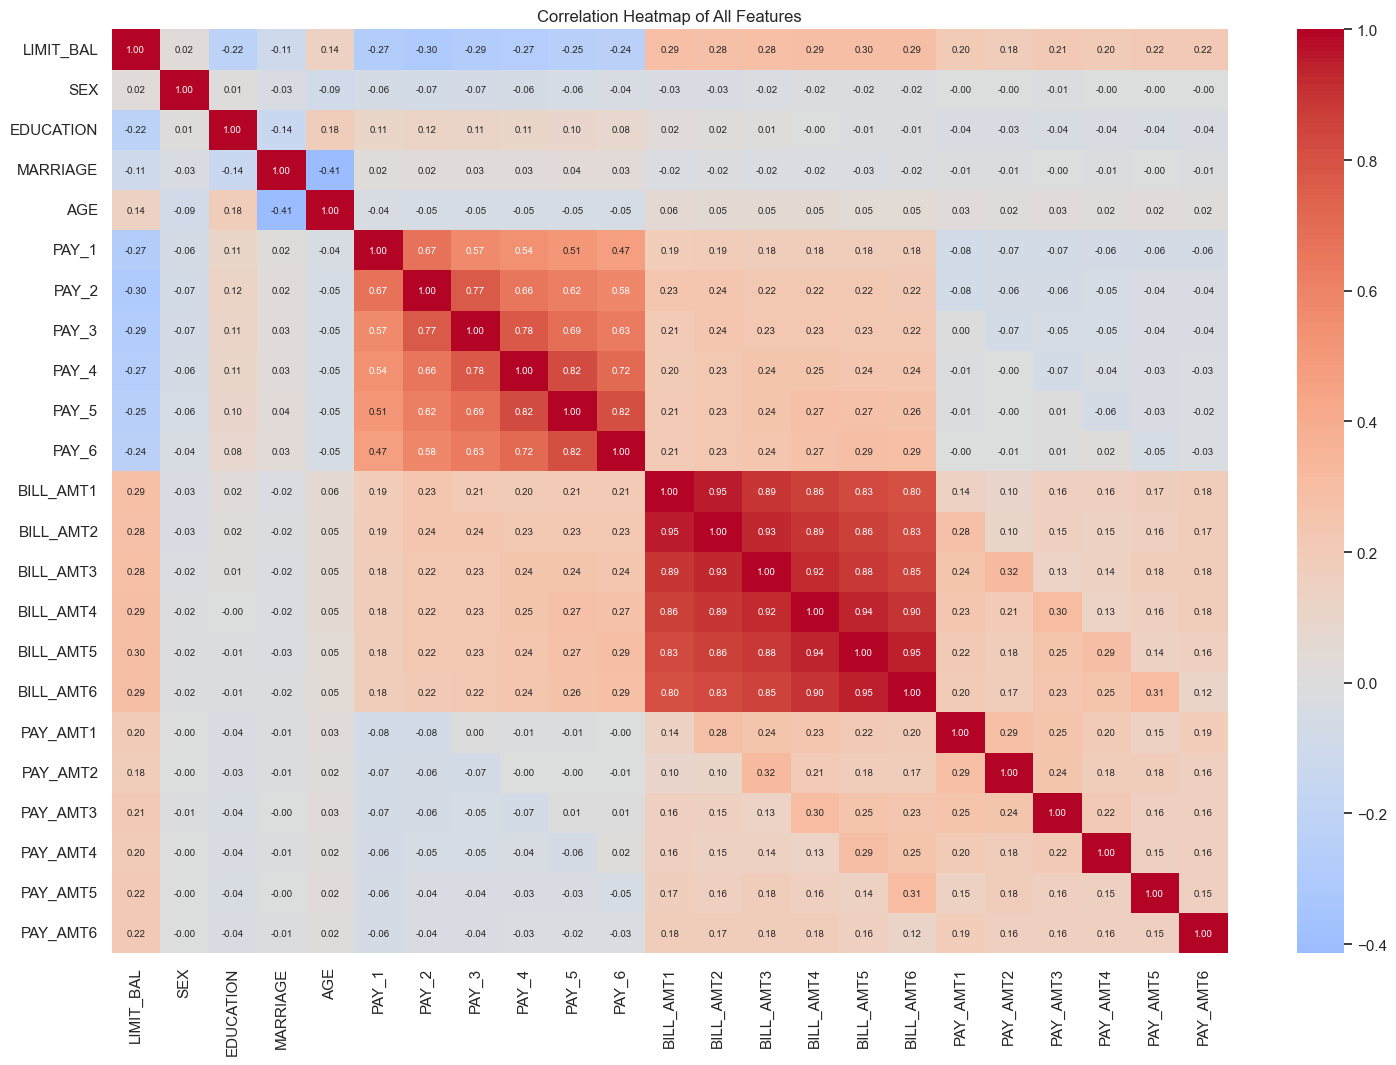

In [4]:
plt.figure(figsize=(18, 12))
corr_matrix = X.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation Heatmap of All Features")
plt.show()

In [5]:
missing_counts = X.isnull().sum()
print("Missing values per column:")
display(missing_counts.to_frame(name="Missing Count"))

Missing values per column:


,Missing Count
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_1,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [6]:
X_clean = X.copy()

print("EDUCATION value counts (before):")
print(X_clean["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE value counts (before):")
print(X_clean["MARRIAGE"].value_counts().sort_index())

# Group undocumented EDUCATION values (0, 5, 6) into one unknown category (0)
X_clean["EDUCATION"] = X_clean["EDUCATION"].replace({5: 0, 6: 0})

# Map undocumented MARRIAGE value 0 into category 3 (other)
X_clean["MARRIAGE"] = X_clean["MARRIAGE"].replace({0: 3})

print("\nEDUCATION value counts (after):")
print(X_clean["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE value counts (after):")
print(X_clean["MARRIAGE"].value_counts().sort_index())

EDUCATION value counts (before):
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts (before):
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

EDUCATION value counts (after):
EDUCATION
0      345
1    10585
2    14030
3     4917
4      123
Name: count, dtype: int64

MARRIAGE value counts (after):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [7]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
X_encoded = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)
display(X_encoded.head())

Encoded feature shape: (30000, 27)


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000.0000,24,2,2,-1,-1,-2,-2,3913.0000,3102.0000,689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,True,False,True,False,False,False,False
1,120000.0000,26,-1,2,0,0,0,2,2682.0000,1725.0000,2682.0000,3272.0000,3455.0000,3261.0000,0.0000,1000.0000,1000.0000,1000.0000,0.0000,2000.0000,True,False,True,False,False,True,False
2,90000.0000,34,0,0,0,0,0,0,29239.0000,14027.0000,13559.0000,14331.0000,14948.0000,15549.0000,1518.0000,1500.0000,1000.0000,1000.0000,1000.0000,5000.0000,True,False,True,False,False,True,False
3,50000.0000,37,0,0,0,0,0,0,46990.0000,48233.0000,49291.0000,28314.0000,28959.0000,29547.0000,2000.0000,2019.0000,1200.0000,1100.0000,1069.0000,1000.0000,True,False,True,False,False,False,False
4,50000.0000,57,-1,0,-1,0,0,0,8617.0000,5670.0000,35835.0000,20940.0000,19146.0000,19131.0000,2000.0000,36681.0000,10000.0000,9000.0000,689.0000,679.0000,False,False,True,False,False,False,False


In [8]:
# Flatten target from 2D to 1D (sklearn requires this)
y_flat = y.values.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_flat, test_size=0.2, random_state=42, stratify=y_flat
)

y_train = pd.Series(y_train, index=X_train.index)
y_test = pd.Series(y_test, index=X_test.index)
X_train = X_train.copy()
X_test = X_test.copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24000, 27)
X_test shape: (6000, 27)
y_train shape: (24000,)
y_test shape: (6000,)


In [9]:
# PAY_1 through PAY_6 are ordinal status categories, so they are intentionally excluded from scaling
continuous_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]

scaler = StandardScaler()

# fit on train only, then transform both
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

display(X_train[continuous_cols].head())

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
22788,-0.0569,-0.2646,1.5055,1.7451,1.7789,1.8917,2.0208,2.0963,0.5807,-0.2903,-0.2978,0.0870,0.5004,0.0487
29006,-0.1341,-0.1558,-0.6952,-0.6911,-0.6851,-0.6738,-0.6625,-0.6521,-0.3450,-0.2903,-0.2978,-0.3181,-0.3170,-0.2930
16950,-1.2151,1.5843,-0.5568,-0.5768,-0.5616,-0.5479,-0.5268,-0.5105,-0.3481,-0.2271,-0.2331,-0.2986,-0.2967,-0.2370
22280,0.4064,-0.6996,2.1192,2.2872,2.4601,2.7380,1.5092,1.6131,0.2153,0.1541,0.1525,0.0006,0.0086,0.0431
11346,1.1014,-0.3733,-0.6952,-0.6919,-0.6803,-0.6688,-0.6664,-0.6561,-0.3483,-0.2742,-0.2978,-0.3181,-0.3170,-0.2258


In [ ]:
print("Number of features scaler was fitted on:", scaler.n_features_in_)
print("Feature names:", scaler.feature_names_in_)


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0     0.8688    0.6927    0.7708      4673
           1     0.3685    0.6315    0.4654      1327

    accuracy                         0.6792      6000
   macro avg     0.6186    0.6621    0.6181      6000
weighted avg     0.7581    0.6792    0.7033      6000



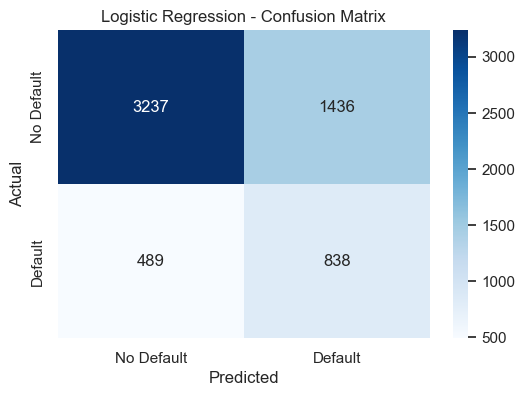


Final Results:
Model: Logistic Regression
Accuracy: 0.6791666666666667
Precision: 0.3685136323658751
Recall: 0.6314996232102487
F1-Score: 0.4654262704804221


In [10]:
# Initialize Logistic Regression model
model = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced")

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Store predictions (optional, if needed later)
predictions = y_pred

# Print results
print("\n" + "=" * 60)
print("Logistic Regression - Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics
results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
}

print("\nFinal Results:")
for key, value in results.items():
    print(f"{key}: {value}")


Tuned Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0     0.8689    0.6936    0.7714      4673
           1     0.3692    0.6315    0.4659      1327

    accuracy                         0.6798      6000
   macro avg     0.6190    0.6625    0.6187      6000
weighted avg     0.7584    0.6798    0.7038      6000



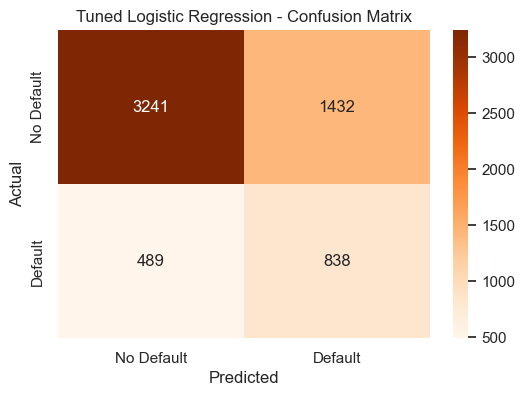


Final Results:
Model: Tuned Logistic Regression
Accuracy: 0.6798333333333333
Precision: 0.36916299559471366
Recall: 0.6314996232102487
F1-Score: 0.46594384209063106


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Tuned Logistic Regression model
tuned_model = LogisticRegression(
    max_iter=3000,
    solver="saga",
    C=0.5,
    class_weight="balanced",
    random_state=42
)

# Train model
tuned_model.fit(X_train, y_train)

# Predict
y_pred = tuned_model.predict(X_test)

# Store predictions (optional)
predictions = y_pred

# Print classification report
print("\n" + "=" * 60)
print("Tuned Logistic Regression - Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics
results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
}

print("\nFinal Results:")
for key, value in results.items():
    print(f"{key}: {value}")

In [14]:
import joblib
joblib.dump(tuned_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [15]:
print("Number of features model expects:", model.n_features_in_)
print("Feature names model was trained on:")
print(list(model.feature_names_in_))

Number of features model expects: 27
Feature names model was trained on:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']
